In [2]:
from collections import Counter

def calcular_frequencias_positivas(frases_positivas):
  freq_palavras = Counter()
  palavras = []
  for frase in frases_positivas:
    palavras = frase.split()
    freq_palavras.update(palavras)
  return freq_palavras


def calcular_frequencias_negativas(frases_positivas):
  freq_palavras = Counter()
  palavras = []
  for frase in frases_positivas:
    palavras = frase.split()
    freq_palavras.update(palavras)
  return freq_palavras

def somatorio_frequencias_positivas(freq_palavras,frase):
  palavras = frase.split()
  soma = 0
  for palavra in palavras:
    soma += freq_palavras[palavra]
  return soma

def somatorio_frequencias_negativas(freq_palavras,frase):
  palavras = frase.split()
  soma = 0
  for palavra in palavras:
    soma += freq_palavras[palavra]
  return soma


In [3]:
freqs_pos = calcular_frequencias_positivas(frases_positivas)

In [4]:
freqs_neg = calcular_frequencias_negativas(frases_negativas)

In [5]:
print(somatorio_frequencias_negativas(freqs_neg,"I hate this stuff"))
print(somatorio_frequencias_positivas(freqs_pos,"I hate this stuff"))

5
5


In [6]:
print(somatorio_frequencias_negativas(freqs_neg,"I love it"))
print(somatorio_frequencias_positivas(freqs_pos,"I love it"))

3
6


## Stemming: somente radical da palavra

In [7]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("english")



In [8]:
def stemming_frase(frase,stemmer):
  frase_nova = []
  for palavra in frase.split():
    frase_nova.append(stemmer.stem(palavra))
  return frase_nova

In [9]:
stemming_frase("I am loving it",stemmer)

['i', 'am', 'love', 'it']

## Lowercase: tudo minusculo

In [10]:
def lowercase_frase(frase):
  frase_nova = []
  for palavra in frase:
    frase_nova.append(palavra.lower())
  return frase_nova

## Stopword removal: remoção completa de stopwords, que não são úteis para a classificação textual

In [12]:
import nltk
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
def remover_stopwords_frase(frase,stop_words):
  frase_nova = []
  for palavra in frase:
    if palavra not in stop_words:
      frase_nova.append(palavra)
  return frase_nova

In [14]:
remover_stopwords_frase("I am loving it",stop_words)

['I', ' ', ' ', 'l', 'v', 'n', 'g', ' ']

## Analisando sentimentos de review de filmes com Regressão Logistica

A seguir, ocorre o processo completo de pré-processamento (tokenização, lowercase, stemming) do dataset ***movie_reviews*** da biblioteca nltk, além do treino e validação de um modelo de regressão logística.

A partir dos dados brutos, é feita a soma da frequência das palavras presentes no texto olhando o vocabulário de frequências positivas e negativas. Com isso, esses dados são passados à um modelo de regressão logistica, que, após treinado, possui pesos aprendidos para **bias, somatório de frequências positivas e também negativas**.

Com todo esse processo, enfim é feito a predição sentimental das reviews dos filmes, retornando 0 para reviews negativas e 1 caso contrário.

Todo o processo foi feito com bibliotecas do nltk, numpy, math e random, não utilizando de arquiteturas mais avançadas disponibilizadas pelo tensorflow ou pytorch.

A biblioteca matplotlib foi utilizada apenas para fins de visualização dos resultados obtidos ao passar das etapas.

In [16]:
import nltk
from nltk.corpus import movie_reviews

import matplotlib.pyplot as plt
import random

In [17]:
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

In [18]:
positive_fileids = movie_reviews.fileids('pos')
negative_fileids = movie_reviews.fileids('neg')

all_positive_reviews = [movie_reviews.raw(fileid) for fileid in positive_fileids]
all_negative_reviews = [movie_reviews.raw(fileid) for fileid in negative_fileids]

In [19]:
print('Number of positive reviews: ', len(all_positive_reviews))
print('Number of negative reviews: ', len(all_negative_reviews))

print('\nThe type of all_positive_reviews is: ', type(all_positive_reviews))
print('The type of a review entry is: ', type(all_negative_reviews[0]))

Number of positive reviews:  1000
Number of negative reviews:  1000

The type of all_positive_reviews is:  <class 'list'>
The type of a review entry is:  <class 'str'>


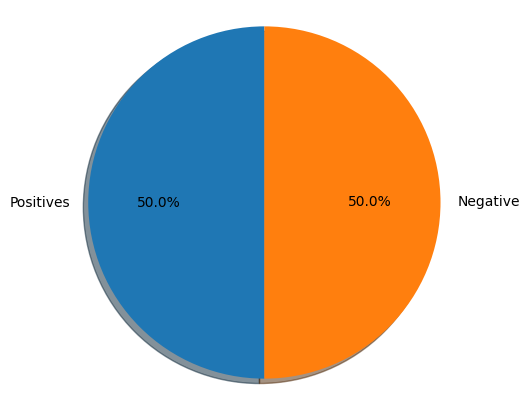

In [20]:
fig = plt.figure(figsize=(5, 5))

labels = 'Positives', 'Negative'

sizes = [len(all_positive_reviews), len(all_negative_reviews)]

plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)

plt.axis('equal')

plt.show()

### Exemplo review positiva (em verde) e negativa (em vermelho).

In [21]:
print('\033[92m' + all_positive_reviews[random.randint(0,len(all_positive_reviews))])
print('\033[91m' + all_negative_reviews[random.randint(0,len(all_negative_reviews))])

bruce willis stars as malcolm , an award winning child psychologist who discovers one night that one of his former patients is still suffering from inner demons . 
the now grown man breaks into his apartment while he and his wife ( olivia williams from rushmore ) are celebrating his award , shoots malcolm in the stomach , then takes his own life . 
almost nine months later , malcolm discovers cole ( haley joel osment , in a brilliant performance ) , another young man afflicted with the same turmoil as his former patient . 
he takes on the child's case in the hope of redeeming himself for botching up the previous one , alienating his wife in the process . 
he soon discovers that they boy can see and speak to the dead , and his life becomes forever turned upside down . 
although the first hour is very slow , the sixth sense turns out to be a very powerful and moving film . 
i was expecting this film to be mercury rising 2 , but was astonished to discover an extremely well plotted out lit

## Tokenizar

In [22]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [23]:
least = ""
import math
lenght_vector = math.inf
for x in range(len(all_positive_reviews)):
  if len(all_positive_reviews[x]) < lenght_vector:
    least = all_positive_reviews[x]
    lenght_vector = len(least)


In [24]:
tokens_test = word_tokenize(least)
tokens_test

['kolya',
 'is',
 'one',
 'of',
 'the',
 'richest',
 'films',
 'i',
 "'ve",
 'seen',
 'in',
 'some',
 'time',
 '.',
 'zdenek',
 'sverak',
 'plays',
 'a',
 'confirmed',
 'old',
 'bachelor',
 '(',
 'who',
 "'s",
 'likely',
 'to',
 'remain',
 'so',
 ')',
 ',',
 'who',
 'finds',
 'his',
 'life',
 'as',
 'a',
 'czech',
 'cellist',
 'increasingly',
 'impacted',
 'by',
 'the',
 'five-year',
 'old',
 'boy',
 'that',
 'he',
 "'s",
 'taking',
 'care',
 'of',
 '.',
 'though',
 'it',
 'ends',
 'rather',
 'abruptly',
 '--',
 'and',
 'i',
 "'m",
 'whining',
 ',',
 "'cause",
 'i',
 'wanted',
 'to',
 'spend',
 'more',
 'time',
 'with',
 'these',
 'characters',
 '--',
 'the',
 'acting',
 ',',
 'writing',
 ',',
 'and',
 'production',
 'values',
 'are',
 'as',
 'high',
 'as',
 ',',
 'if',
 'not',
 'higher',
 'than',
 ',',
 'comparable',
 'american',
 'dramas',
 '.',
 'this',
 'father-and-son',
 'delight',
 '--',
 'sverak',
 'also',
 'wrote',
 'the',
 'script',
 ',',
 'while',
 'his',
 'son',
 ',',
 'jan'

## Remover Stopwords

In [25]:
import string
stopwords_english = stopwords.words('english')

print('Stop words\n')
print(stopwords_english[:10])

print('\nPunctuation\n')
print(string.punctuation)

Stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

Punctuation

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


## Stemming

Aqui ocorre a obtenção do radical da palavra, que é a parte base que carrega o significado principal e a partir da qual podem ser formadas variações.

> Exemplo: "am" é o radical de "amar","amava", "amarei"




In [26]:
def stemming_frase(frase,stemmer):
  frase_nova = []
  for palavra in frase:
    frase_nova.append(stemmer.stem(palavra))
  return frase_nova

### Exemplo de stemming em ação

In [27]:
stemming_frase(tokens_test,stemmer)

['kolya',
 'is',
 'one',
 'of',
 'the',
 'richest',
 'film',
 'i',
 've',
 'seen',
 'in',
 'some',
 'time',
 '.',
 'zdenek',
 'sverak',
 'play',
 'a',
 'confirm',
 'old',
 'bachelor',
 '(',
 'who',
 "'s",
 'like',
 'to',
 'remain',
 'so',
 ')',
 ',',
 'who',
 'find',
 'his',
 'life',
 'as',
 'a',
 'czech',
 'cellist',
 'increas',
 'impact',
 'by',
 'the',
 'five-year',
 'old',
 'boy',
 'that',
 'he',
 "'s",
 'take',
 'care',
 'of',
 '.',
 'though',
 'it',
 'end',
 'rather',
 'abrupt',
 '--',
 'and',
 'i',
 "'m",
 'whine',
 ',',
 'caus',
 'i',
 'want',
 'to',
 'spend',
 'more',
 'time',
 'with',
 'these',
 'charact',
 '--',
 'the',
 'act',
 ',',
 'write',
 ',',
 'and',
 'product',
 'valu',
 'are',
 'as',
 'high',
 'as',
 ',',
 'if',
 'not',
 'higher',
 'than',
 ',',
 'compar',
 'american',
 'drama',
 '.',
 'this',
 'father-and-son',
 'delight',
 '--',
 'sverak',
 'also',
 'wrote',
 'the',
 'script',
 ',',
 'while',
 'his',
 'son',
 ',',
 'jan',
 ',',
 'direct',
 '--',
 'won',
 'a',
 'go

In [28]:
tokens_test

['kolya',
 'is',
 'one',
 'of',
 'the',
 'richest',
 'films',
 'i',
 "'ve",
 'seen',
 'in',
 'some',
 'time',
 '.',
 'zdenek',
 'sverak',
 'plays',
 'a',
 'confirmed',
 'old',
 'bachelor',
 '(',
 'who',
 "'s",
 'likely',
 'to',
 'remain',
 'so',
 ')',
 ',',
 'who',
 'finds',
 'his',
 'life',
 'as',
 'a',
 'czech',
 'cellist',
 'increasingly',
 'impacted',
 'by',
 'the',
 'five-year',
 'old',
 'boy',
 'that',
 'he',
 "'s",
 'taking',
 'care',
 'of',
 '.',
 'though',
 'it',
 'ends',
 'rather',
 'abruptly',
 '--',
 'and',
 'i',
 "'m",
 'whining',
 ',',
 "'cause",
 'i',
 'wanted',
 'to',
 'spend',
 'more',
 'time',
 'with',
 'these',
 'characters',
 '--',
 'the',
 'acting',
 ',',
 'writing',
 ',',
 'and',
 'production',
 'values',
 'are',
 'as',
 'high',
 'as',
 ',',
 'if',
 'not',
 'higher',
 'than',
 ',',
 'comparable',
 'american',
 'dramas',
 '.',
 'this',
 'father-and-son',
 'delight',
 '--',
 'sverak',
 'also',
 'wrote',
 'the',
 'script',
 ',',
 'while',
 'his',
 'son',
 ',',
 'jan'

## Lowercase

É um padrão em modelos textuais transformar o texto em forma minúscula antes do processamento. Isso se dá pois palavras de diferentes formatos são lidas de formas diferentes pelo modelo, o que pode gerar resultados inesperados.



> Ex: "Oi" e "oi" podem, se não tratadas, ter frequências distintas, uma ocorrendo em reviews positivas e outra em negativas, o que não faz sentido.



In [101]:
def lowercase_frase(frase):
  frase_nova = []
  for palavra in frase:
    frase_nova.append(palavra.lower())
  return frase_nova

### Stopwords e Pontuações

Outra padronização feita é a remoção de **stopwords**, que nada mais são que palavras como artigos ou palavras que não incrementam no contexto textual e não são palavras-chave. Essa remoção é feita em casos em que sua presença não é vantajosa para a tarefa de classificação textual.

Como a análise de revisões de filmes têm o foco maior em palavras essenciais como substantivos, isso é uma tarefa vantajosa.

Para isso, bibliotecas como nltk oferecem uma lista de stopwords em diferentes linguagens, o que facilita o processo.

Da mesma forma, pontuações e outros símbolos como emojis também são removidos para evitar que o modelo se baseie de alguma forma neles para realizar a predição.

In [30]:
def remover_stopwords_frase(frase,stop_words):
  frase_nova = []
  for palavra in frase:
    if palavra not in stop_words:
      frase_nova.append(palavra)
  return frase_nova

In [31]:
def remove_pontuation_frase(frase):
  frase_nova = []
  for palavra in frase:
      if palavra not in string.punctuation:
          frase_nova.append(palavra)

  return frase_nova

## Juntando todo o pré-processamento em um pipeline

A seguir pode se ver como cada etapa de pré-processamento se conecta e realiza a modificação textual, e com isso, os textos ficam prontos para a etapa de treinamento do modelo.

In [32]:
reviews_positivos_filtrado = []
reviews_negativos_filtrado = []
import random
print(15* "=" + "Reviews Positivos" + 15 * "=")
for frase in all_positive_reviews:
  frase = word_tokenize(frase)
  nova_frase = stemming_frase(frase,stemmer)
  nova_frase = lowercase_frase(nova_frase)
  nova_frase = remove_pontuation_frase(nova_frase)
  nova_frase = remover_stopwords_frase(nova_frase,stop_words)
  reviews_positivos_filtrado.append(nova_frase)
  if random.randint(0,100) == 42:
      print(nova_frase)
print(30* "=" + len("Reviews Positivas") * "=")
print("\n")
print(15* "=" + "Reviews Negativas" + 15 * "=")
for frase in all_negative_reviews:
  frase = word_tokenize(frase)
  nova_frase = stemming_frase(frase,stemmer)
  nova_frase = lowercase_frase(nova_frase)
  nova_frase = remover_stopwords_frase(nova_frase,stop_words)
  reviews_negativos_filtrado.append(nova_frase)
  if random.randint(0,100) == 42:
      print(nova_frase)
print(30* "=" + len("Reviews Negativas") * "=")

===============Reviews Positivos===============
['foreign', 'languag', 'film', 'known', 'name', 'select', 'number', 'theater', 'show', '``', 'shall', 'danc', '``', 'wo', "n't", 'seen', 'mani', 'peopl', "'s", 'shame', 'funni', 'enchant', 'goofi', 'movi', 'full', 'laugh', 'surpris', 'wonder', 'danc', 'sequenc', 'surpris', 'thing', '``', 'shall', 'danc', '``', 'univers', 'appeal', 'stori', 'us', 'version', 'work', "'s", 'wonder', "'s", 'realli', 'cultur', 'specif', 'although', 'narrat', 'set-up', 'add', 'extra', 'reson', 'proceed', 'view', 'japanes', 'cultur', 'ballroom', 'danc', 'movi', 'rich', 'charact', 'appeal', 'ad', 'layer', "n't", 'necessari', 'understand', 'enjoy', 'film', 'onli', 'import', 'unexplain', 'japanese-specif', 'refer', 'may', 'leav', 'bit', 'puzzl', '1000', 'yen', 'rough', '10', 'see', 'film', 'see', 'film', 'know', 'whi', 'middl', 'age', 'compani', 'man', 'realiz', 'achiev', 'goal', 'set', 'life', 'hous', 'child', 'good', 'marriag', 'still', 'doe', "n't", 'translat', 

## Frequências Positivas e Negativas

As frequências representam a soma das ocorrências de palavras previamente classificadas como positivas ou negativas dentro de uma review. Basicamente, o quão frequentemente uma dada palavra ocorre em reviews positivas e negativas.

É com base nessas frequências que será feito o vetor de features para cada frase contendo **[bias, frequencias_positivas, frequencias_negativas]** olhando para esse vocabulário com o número de ocorrências da palavra em cada classe.

In [33]:
def calcular_frequencias_positivas(frases_positivas):
  freq_palavras = Counter()
  palavras = []
  for frase in frases_positivas:
    print
    palavras = " ".join(frase).split()
    freq_palavras.update(palavras)
  return freq_palavras


def calcular_frequencias_negativas(frases_positivas):
  freq_palavras = Counter()
  palavras = []
  for frase in frases_positivas:
    palavras = " ".join(frase).split()
    freq_palavras.update(palavras)
  return freq_palavras

In [34]:
freq_pos_reviews=  calcular_frequencias_positivas(reviews_positivos_filtrado)
freq_neg_reviews = calcular_frequencias_negativas(reviews_negativos_filtrado)

## Detectar tipos frequentes

Aqui é feito, com a biblioteca nltk, uma análise dos tipos de classes textuais mais comuns nas reviews

> Exemplo: adjetivos, substantivos, artigos

Com isso, será feito um pré-processamento removendo aquelas classes com menos de 1% de aparição geral, sendo uma etapa similar a remoção de stopwords, mas agora com instâncias raras (ou **outliers**)


In [35]:
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
tags_pos = pos_tag(freq_pos_reviews)
tags_neg = pos_tag(freq_neg_reviews)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


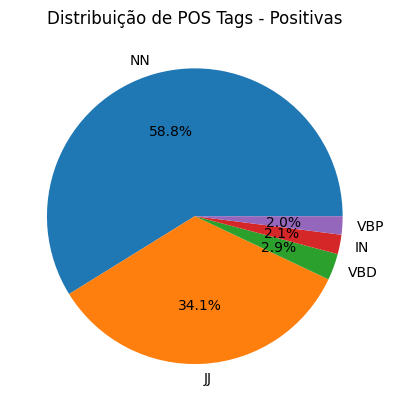

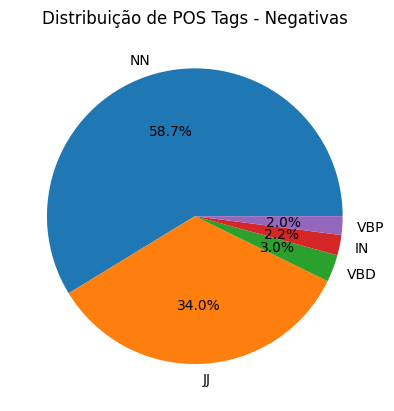

In [36]:
import matplotlib.pyplot as plt
from collections import Counter

pos_tags_only = [tag for word, tag in tags_pos]
pos_counts = dict(Counter(pos_tags_only).most_common(5))

plt.figure()
plt.pie(pos_counts.values(),
        labels=pos_counts.keys(),
        autopct='%1.1f%%')
plt.title("Distribuição de POS Tags - Positivas")
plt.show()


neg_tags_only = [tag for word, tag in tags_neg]
neg_counts = dict(Counter(neg_tags_only).most_common(5))
plt.figure()
plt.pie(neg_counts.values(),
        labels=neg_counts.keys(),
        autopct='%1.1f%%')
plt.title("Distribuição de POS Tags - Negativas")
plt.show()

In [37]:
pos_valid_tags = {
    tag for tag, count in pos_counts.items()
    if (count / len(reviews_positivos_filtrado)) * 100 >= 1
}

neg_valid_tags = {
    tag for tag, count in pos_counts.items()
    if (count / len(reviews_negativos_filtrado)) * 100 >= 1
}


In [38]:
tags_pos_filtered = [
    (word, tag) for word, tag in tags_pos
    if tag in pos_valid_tags
]

tags_neg_filtered = [
    (word, tag) for word, tag in tags_neg
    if tag in neg_valid_tags
]

In [39]:
from collections import Counter

freq_neg_reviews_filtered = {
    word: freq_neg_reviews[word]
    for word, tag in tags_neg_filtered
    if word in freq_neg_reviews
}
freq_pos_reviews_filtered = {
    word: freq_pos_reviews[word]
    for word, tag in tags_pos_filtered
    if word in freq_pos_reviews
}

Com todo o processamento final, temos agora a distribuição de palavras positivas e negativas e é visto um balanceamento é mantido nesse caso também, com um número ligeiramente maior de palavras positivas.

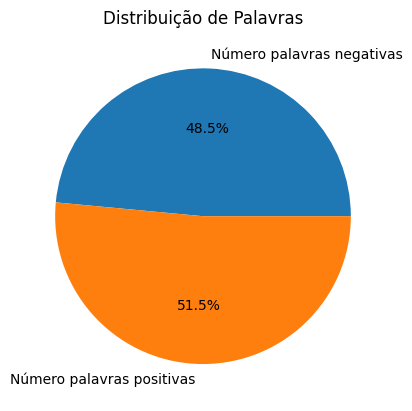

In [40]:
plt.figure()
plt.pie([len(freq_neg_reviews_filtered), len(freq_pos_reviews_filtered)],
        labels=["Número palavras negativas", "Número palavras positivas"],
        autopct='%1.1f%%')
plt.title("Distribuição de Palavras")
plt.show()

## Somatório

Aqui é feito o somatório de frequências positivas e negativas de uma dada frase. Como visto anteriormente, foi obtido um dicionário contendo o número de aparições de cada palavra em reviews negativas e positivas.

Com isso, é possível os comparar com uma dada frase, podendo assim ser feito a etapa de somatório. O que é feito é que, dada uma frase, cada palavra é comparada com os dois dicionários, e uma soma é feita.

A soma é incrementada pelo número de aparições da palavra no dicionário positivo caso essa palavra estiver na frase atual.

> Ex: "love" apareceu 51 vezes em reviews positivas, e aparece em "I loved this movie", portanto, a soma é incrementada por 51.

O mesmo é feito para instâncias negativas, em um somatório diferente.

> Ex: "hate" apareceu 23 vezes em reviews negativas, e aparece em "I hated this movie", portanto, a soma é decrementada por 23.

O resultado são dois somatórios das frequências positivas e negativas.


In [41]:
def somatorio_frequencias_positivas(freq_palavras,frase):
  frase = lowercase_frase(frase)
  frase = remove_pontuation_frase(frase)
  frase = stemming_frase(frase,stemmer)
  frase = remover_stopwords_frase(frase,stop_words)

  palavras = frase
  soma = 0
  for palavra in palavras:
    try:
      soma += freq_palavras[palavra]
    except KeyError:
      pass
  return soma

def somatorio_frequencias_negativas(freq_palavras,frase):
  frase = lowercase_frase(frase)
  frase = remove_pontuation_frase(frase)
  frase = stemming_frase(frase,stemmer)
  frase = remover_stopwords_frase(frase,stop_words)
  palavras = frase
  soma = 0
  for palavra in palavras:
    try:
      soma += freq_palavras[palavra]
    except KeyError:
      pass
  return soma

def vetor_frequencias(bias,soma_positiva,soma_negativa):
    return [bias,soma_positiva,soma_negativa]

In [42]:
pos_test =  somatorio_frequencias_positivas(freq_pos_reviews_filtered,"I really liked the acting and its atmosphere")
neg_test = somatorio_frequencias_negativas(freq_neg_reviews_filtered,"I really liked the acting and its atmosphere")
print(pos_test)
print(neg_test)


911
864


In [43]:
vetor_frequencias(1,pos_test,neg_test)

[1, 911, 864]

 Os valores obtidos são grandes, portanto, a matriz de features X deve ser feita com valores normalizados, o que nad amais é do que uma divisão simples pelo número de tokens




In [44]:
import numpy as np

all_fileids = movie_reviews.fileids()
m = len(all_fileids)
X = np.zeros((m, 3), dtype=float)

for i, fid in enumerate(all_fileids):
    text = movie_reviews.raw(fid)
    tokens = word_tokenize(text.lower())
    L = len(tokens) if len(tokens) > 0 else 1

    pos_x = sum(freq_pos_reviews_filtered.get(w, 0) for w in tokens) / L
    neg_x = sum(freq_neg_reviews_filtered.get(w, 0) for w in tokens) / L

    X[i, :] = [1.0, pos_x, neg_x]

Plottando a distribuição normal das frequências, é visto que as duas não são normais, com uma calda na direita. Porém, ambas possuem médias similares.

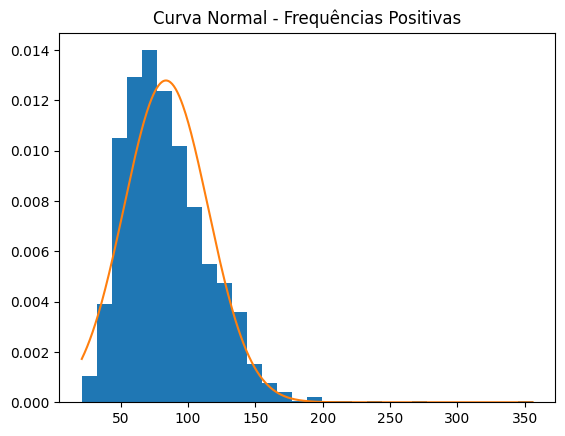

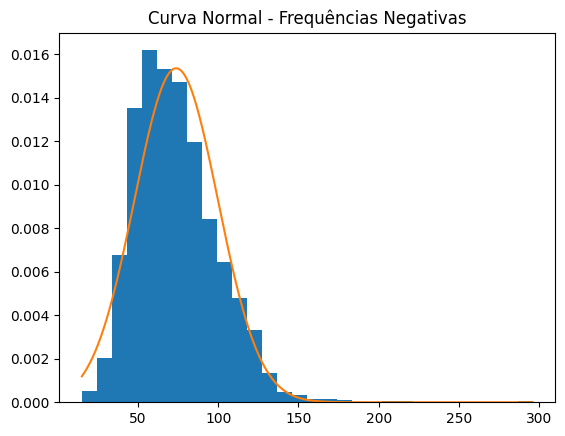

In [45]:
import matplotlib.pyplot as plt

def plot_normal_curve(data, title):
    mu = np.mean(data)
    sigma = np.std(data)

    x = np.linspace(min(data), max(data), 500)
    y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)

    plt.figure()
    plt.hist(data, bins=30, density=True)
    plt.plot(x, y)
    plt.title(title)
    plt.show()


plot_normal_curve(X[:,1], "Curva Normal - Frequências Positivas")

plot_normal_curve(X[:,2], "Curva Normal - Frequências Negativas")


## Análise de Palavras mais frequentes nos dois espectros e também aleatórias

Nota-se que a tendência de palavras mais frequentes é aparecer tanto em reviews positivas quanto negativas. Mas algumas como "like" e "character" tendem a aparecer mais em reviews positivas.

In [47]:
top_pos = sorted(freq_pos_reviews_filtered.items(),
                 key=lambda x: x[1],
                 reverse=True)[:5]

top_neg = sorted(freq_neg_reviews_filtered.items(),
                 key=lambda x: x[1],
                 reverse=True)[:5]

keys = [word for word, _ in top_pos] + \
       [word for word, _ in top_neg]

keys.extend(list(freq_pos_reviews_filtered.keys())[random.randint(0,len(freq_pos_reviews_filtered))] for x in range(5))
keys.extend(list(freq_neg_reviews_filtered.keys())[random.randint(0,len(freq_neg_reviews_filtered))] for x in range(5))

data = []

for word in keys:

    pos = freq_pos_reviews_filtered.get(word, 0)

    neg = freq_neg_reviews_filtered.get(word, 0)

    data.append([word, pos, neg])

data


[['film', 6142, 4967],
 ['movi', 3127, 3734],
 ['charact', 2055, 1802],
 ['like', 1942, 2048],
 ['make', 1652, 1503],
 ['film', 6142, 4967],
 ['movi', 3127, 3734],
 ['like', 1942, 2048],
 ['charact', 2055, 1802],
 ['make', 1652, 1503],
 ['benben', 2, 0],
 ['profit', 24, 15],
 ['disintegr', 7, 1],
 ['ussr', 2, 0],
 ['hour-and-a-half', 1, 1],
 ['winger', 0, 1],
 ['ten-foot', 0, 1],
 ['hannib', 3, 5],
 ['break-into-the-build', 0, 1],
 ['high-school', 9, 6]]

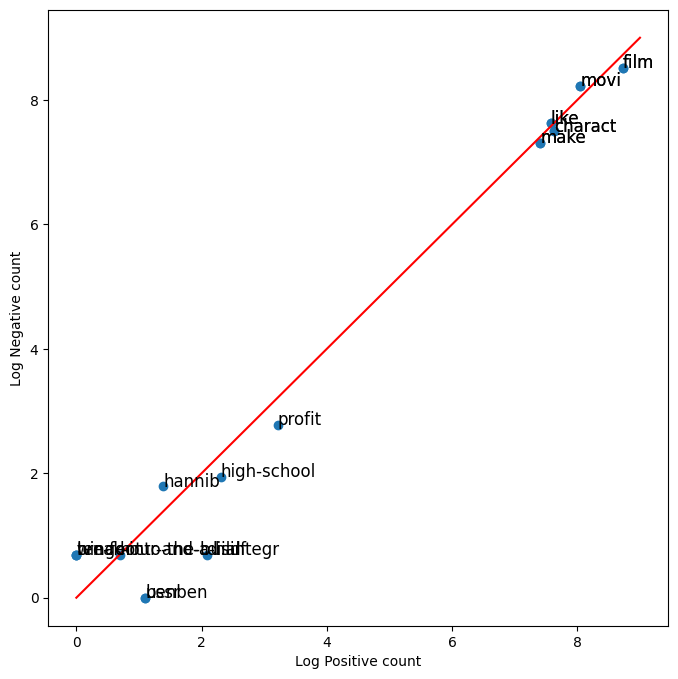

In [48]:
fig, ax = plt.subplots(figsize = (8, 8))

x = np.log([x[1] + 1 for x in data])

y = np.log([x[2] + 1 for x in data])

ax.scatter(x, y)

plt.xlabel("Log Positive count")
plt.ylabel("Log Negative count")

for i in range(0, len(data)):
    ax.annotate(data[i][0], (x[i], y[i]), fontsize=12)

ax.plot([0, 9], [0, 9], color = 'red')
plt.show()

## Regressão Logistica


In [51]:
n = X.shape[1]
theta = np.zeros((n, 1))

In [52]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [53]:
X[0]

array([ 1.        , 95.12009512, 91.48870392])

In [54]:
z = X[random.randint(1,len(X))] @ theta
h = sigmoid(z)
print(h)

[0.5]


### Custo e Gradiente

In [55]:
def compute_cost(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    cost = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
    return cost


In [56]:
theta0 = np.zeros((X.shape[1], 1))
print("cost(theta=0):", compute_cost(X, y, theta0))


cost(theta=0): 1386.294361119891


In [57]:
def compute_gradient(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    grad = (1/m) * (X.T @ (h - y))
    return grad


In [58]:
import numpy as np
from nltk.corpus import movie_reviews

all_fileids = movie_reviews.fileids()
m = len(all_fileids)

y = np.zeros((m, 1))

for i, fid in enumerate(all_fileids):
    if movie_reviews.categories(fid)[0] == 'pos':
        y[i] = 1


In [59]:
print("X:", X.shape, "theta:", theta.shape, "y:", y.shape)
print("y unique:", np.unique(y))
print("cost now:", compute_cost(X, y, theta))


X: (2000, 3) theta: (3, 1) y: (2000, 1)
y unique: [0. 1.]
cost now: 0.6931471805599454


In [60]:
Xn = X.copy()
mu = Xn[:,1:].mean(axis=0)
sigma = Xn[:,1:].std(axis=0)
Xn[:,1:] = (Xn[:,1:] - mu) / sigma


### Treino

O treino é feito com 100.000 iterações, com um alpha relativamente alto (0.01).

In [61]:
alpha = 0.01

theta = np.zeros((Xn.shape[1], 1))
costs = []

for i in range(100000):
    grad = compute_gradient(Xn, y, theta)
    theta -= alpha * grad
    if i % 10000 == 0:
        c = compute_cost(Xn, y, theta)
        costs.append(c)
        print(i, c)




0 0.6931404233144749
10000 0.6497819846652092
20000 0.6294879018693832
30000 0.6192400963578761
40000 0.613736715536592
50000 0.6106455694349004
60000 0.6088519264793479
70000 0.6077859694647627
80000 0.6071410496144527
90000 0.6067455417853603


### Mostrando os pesos obtidos

Nota-se que os pesos obtidos indicam um bias próximo à zero (-0.017), ou seja, com pouca influência. Além disso, os pesos positivos e negativos, de forma modular, se apresentam bem similares. Isso pode ser explicado pelo balanceamento do dataset e das features, pois, como visto, tem-se um número praticamente igual de exemplos nas duas classes, e, portanto, não há tendência inicial para classes positivas ou negativas.

O modelo então funciona da forma:

$$
z \propto freq_{pos} - freq_{neg}
$$


Onde classifica a review como positiva ou negativa dependendo do número de palavras tendendo ao positivo ou negativo que possui.

In [62]:
print(theta.ravel())


[-0.01707708  5.04000285 -5.06043878]


In [63]:
y

array([[0.],
       [0.],
       [0.],
       ...,
       [1.],
       [1.],
       [1.]])

Pode-se ver, além disso, que que é difícil separar as classes positivas e nagativas claramente em 2D, e se intercalavam fortemente.


In [65]:
def neg(theta, pos):
    return (-theta[0] - pos * theta[1]) / theta[2]

def direction(theta):
    return -theta[1] / theta[2]

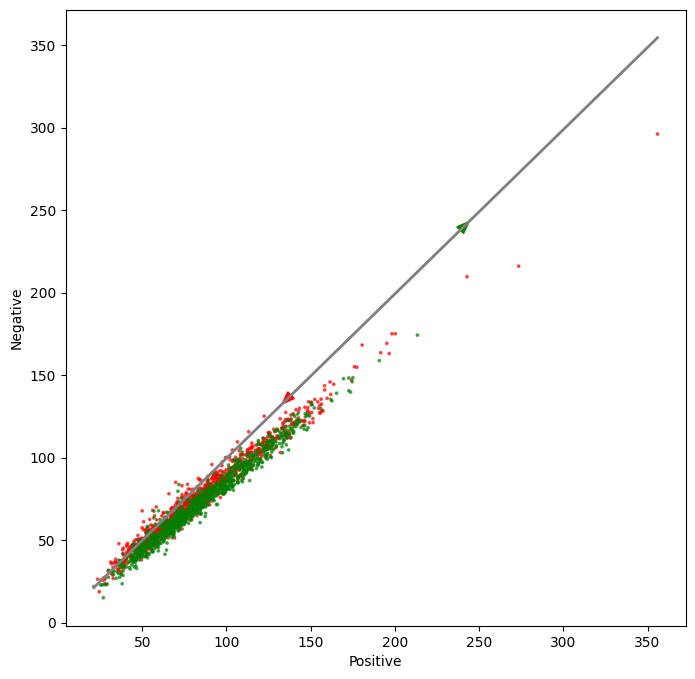

In [66]:
y_flat = y.reshape(-1)
theta_flat = theta.reshape(-1)
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['red', 'green']

ax.scatter(X[:, 1], X[:, 2],
           c=[colors[int(k)] for k in y_flat],
           s=3, alpha=0.6)

ax.set_xlabel("Positive")
ax.set_ylabel("Negative")

minpos = np.min(X[:, 1])
maxpos = np.max(X[:, 1])

x_line = np.array([minpos, maxpos])
y_line = neg(theta_flat, x_line)

ax.plot(x_line, y_line, color='gray', linewidth=2)

pos0 = (minpos + maxpos) / 2
neg0 = neg(theta_flat, pos0)

dx = (maxpos - minpos) * 0.15
dy = direction(theta_flat) * dx

ax.arrow(pos0, neg0, dx, dy,
         head_width=(np.max(X[:,2]) - np.min(X[:,2])) * 0.02,
         head_length=dx * 0.15,
         fc='g', ec='g')

ax.arrow(pos0, neg0, -dx, -dy,
         head_width=(np.max(X[:,2]) - np.min(X[:,2])) * 0.02,
         head_length=dx * 0.15,
         fc='r', ec='r')

plt.show()



### Prevendo novos exemplos

In [103]:
def predict_review(frase, freq_pos, freq_neg, theta):
    frase = word_tokenize(frase)
    frase = lowercase_frase(frase)
    frase = remove_pontuation_frase(frase)
    frase = stemming_frase(frase, stemmer)
    frase = remover_stopwords_frase(frase, stop_words)
    print(frase)
    L = len(frase) if len(frase) > 0 else 1

    pos_soma = somatorio_frequencias_positivas(freq_pos, frase) / L
    neg_soma = somatorio_frequencias_negativas(freq_neg, frase) / L

    x = vetor_frequencias(1, pos_soma, neg_soma)

    theta = np.array(theta).reshape(-1)
    x = np.array(x).reshape(-1)

    y_pred = sigmoid(x @ theta)
    classe = int(y_pred >= 0.5)
    print(f"Soma Frequências Positivas: {pos_soma}")
    print(f"Soma Frequências Negativas: {neg_soma}")
    return "positiva" if classe == 1 else "negativa"


#### Nota-se que uma review claramente negativa, com palavras como "hated" ou "awful" possui uma soma de frequências negativas bem maior, fazendo o modelo prever a review como negativa.

In [105]:
resultado = predict_review("This was awful and I hated it", freq_pos_reviews_filtered,freq_neg_reviews_filtered, theta)
print(f"A review foi predita como {resultado}")

['aw', 'hate']
Soma Frequências Positivas: 68.0
Soma Frequências Negativas: 127.0
A review foi predita como negativa
